### Maximal Cluster Evolution

We use the maximal cluster evolution as a time series measure to identify
possible criticality, following the approach proposed by Shinoda and Kaneko,

-> Shinoda, K., \& Kaneko, K. (2016), *Chaotic Griffiths Phase with Anomalous
Lyapunov Spectra in Coupled Map Networks*, arXiv:1605.02191.



In [1]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import numba
from numba import njit, prange
from collections import Counter

In [2]:
# Local Dynamics
@njit(parallel=False)
def fx(xold,yold,d):
    fxn=(xold**2)*(np.exp(yold-xold))+d
    return fxn
@njit(parallel=False)
def fy(xold,yold):
    fyn=a*(yold)-q*(xold)+c
    return fyn
#System evolution
def xn(fxn):
    xnew = (1-eps)*fxn + eps*np.mean(fxn)    
    return xnew

In [3]:
#parameters
N = 1000
b=400
T=100000
a=0.89
q=0.18
c=0.28

#Global Evolution 
def GCM(eps):
    initialx = np.random.uniform(1, 3, N)
    initialy = np.random.uniform(1, 4, N)
    x_s = np.zeros((T,N)) #to do transients
    y_s = np.zeros((T,N)) #to do transients
    heterogeniety = np.random.uniform(0.026, 0.03, N) #heterogeneity
    x_s[0,:] = initialx
    y_s[0,:] = initialy
    for t in range(T-1):
        f_xj = fx(initialx, initialy, heterogeniety)
        f_yj = fy(initialx, initialy)
        x_s[t+1, :]= xn(f_xj)
        y_s[t+1, :]= f_yj
        initialx = x_s[t+1, :]
        initialy = y_s[t+1, :]
    return x_s

In [4]:
# Clustering Counting
def counting_clus(connections):
    delta=0.00001
    counts = []
    count=0
    for num in connections:
        if num < delta:
            count = count + 1
        else:
            #We count first arraw upper than diagonal    
            if count > 0:
                counts.append(count + 1) 
            count = 0
    if count > 0:
        counts.append(count + 1)
    return counts

In [5]:
#CASE 1
eps=0.13
states=GCM(eps)
S_matrix =np.zeros((b, N))
for tiempo in range(0,b):
    S_matrix[tiempo]=states[T-b+tiempo]
data_0=S_matrix
all_clusters=[]
Max_clus = []
instant_clust2 = []

for ij in range(len(data_0)): 
    data= np.sort(data_0[ij]) 
    distance = np.abs(np.subtract.outer(data, data).T) #Matrix of distances of each list
    arr2 = np.diag(distance, 1) 
    connections = list(arr2)
    clusters_list = counting_clus(connections)
    all_clusters.extend(clusters_list)
    instant_clust2.append(list(Counter(clusters_list).keys()))
    sort_clus = np.sort(instant_clust2[ij])
    max_clust = sort_clus[-1]
    Max_clus.append(max_clust)
x_axis = np.arange(0, len(data_0), 1)

In [6]:
#CASE 2
eps=0.22
states=GCM(eps)
S_matrix =np.zeros((b, N))
for tiempo in range(0,b):
    S_matrix[tiempo]=states[T-b+tiempo]
data_0=S_matrix
all_clusters=[]
Max_clus_1 = []
instant_clust2 = []

for ij in range(len(data_0)): 
    data= np.sort(data_0[ij]) 
    distance = np.abs(np.subtract.outer(data, data).T) #Matrix of distances of each list
    arr2 = np.diag(distance, 1) 
    connections = list(arr2)
    clusters_list = counting_clus(connections)
    all_clusters.extend(clusters_list)
    instant_clust2.append(list(Counter(clusters_list).keys())) 
    sort_clus = np.sort(instant_clust2[ij])
    max_clust = sort_clus[-1]
    Max_clus_1.append(max_clust)
x_axis = np.arange(0, len(data_0), 1)

In [7]:
#CASE 3
eps=0.3
states=GCM(eps)
S_matrix =np.zeros((b, N))
for tiempo in range(0,b):
    S_matrix[tiempo]=states[T-b+tiempo]
data_0=S_matrix
all_clusters=[]
Max_clus_2 = []
instant_clust2 = []

for ij in range(len(data_0)): 
    data= np.sort(data_0[ij]) 
    distance = np.abs(np.subtract.outer(data, data).T) #Matrix of distances of each list
    arr2 = np.diag(distance, 1) 
    connections = list(arr2)
    clusters_list = counting_clus(connections)
    all_clusters.extend(clusters_list)
    instant_clust2.append(list(Counter(clusters_list).keys())) 
    sort_clus = np.sort(instant_clust2[ij])
    max_clust = sort_clus[-1]
    Max_clus_2.append(max_clust)
x_axis = np.arange(0, len(data_0), 1)

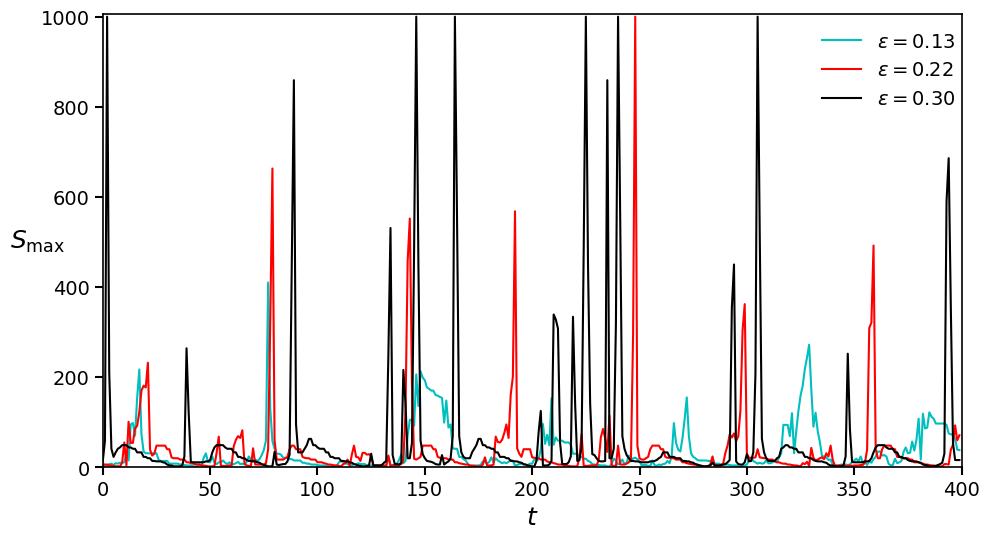

In [11]:
from mpl_toolkits.mplot3d.art3d import rotate_axes


plt.figure(figsize=(10, 5.5))
plt.plot(x_axis, Max_clus, 'c-', linewidth=1.5, label='$\epsilon = 0.13$')
plt.plot(x_axis, Max_clus_1, 'r-', linewidth=1.5, label='$\epsilon = 0.22$')
plt.plot(x_axis, Max_clus_2, 'k-', linewidth=1.5, label='$\epsilon = 0.30$')


ax = plt.gca()
for axis in ['top', 'bottom', 'left', 'right']:
    ax.spines[axis].set_linewidth(1.2)
    ax.spines[axis].set_edgecolor('black')
ax.tick_params(axis='both', which='major', labelsize=14, width=1.5, length=6)

plt.xlabel("$t$", fontsize=18)
plt.ylabel("$S_{\max}$", fontsize=18, labelpad=2, va='center', rotation=0)
plt.legend(
    loc='upper center', 
    bbox_to_anchor=(0.915, 1), 
    fontsize=14, 
    frameon=False, 
    edgecolor='black', 
    framealpha=1,
    markerscale=2,  
    labelspacing=0.5
)
plt.xlim(0, 400)
plt.ylim(0, 1005)
plt.grid(False)

plt.tight_layout()
plt.savefig("Fig4_Max_Clus_Evolution.pdf", format='pdf', dpi=300)
plt.show()
